In [34]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("mps" if torch.cuda.is_available() else "cpu")
print(device)
print(f"PyTorch version: {torch.__version__}")

cpu
PyTorch version: 2.8.0


In [24]:
import joblib

X_train_seq = joblib.load("X_train_seq.pkl")
y_train_seq = joblib.load("y_train_seq.pkl")
X_val_seq = joblib.load("X_val_seq.pkl")
y_val_seq = joblib.load("y_val_seq.pkl")
X_test_seq = joblib.load("X_test_seq.pkl")

print("Data loaded successfully.")
print({k: v.shape for k, v in X_train_seq.items()})
print(f"y_train_seq shape: {y_train_seq.shape}")
print({k: v.shape for k, v in X_val_seq.items()})
print(f"y_val_seq shape: {y_val_seq.shape}")

input_shape = X_train_seq['cont'].shape[1:]

Data loaded successfully.
{'cont': torch.Size([5346, 32, 30]), 'survey': torch.Size([5346, 32, 4]), 'body': torch.Size([5346, 32, 1]), 'time': torch.Size([5346, 32, 1])}
y_train_seq shape: torch.Size([5346])
{'cont': torch.Size([603, 32, 30]), 'survey': torch.Size([603, 32, 4]), 'body': torch.Size([603, 32, 1]), 'time': torch.Size([603, 32, 1])}
y_val_seq shape: torch.Size([603])


In [25]:
from torch import nn

# Hyperparameters

BATCH_SIZE = 128

# Training configuration
LEARNING_RATE = 5e-4
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2        
HIDDEN_SIZE = 64        

# Regularization
DROPOUT_RATE = 0.45       
L1_LAMBDA = 0         
L2_LAMBDA = 2e-4        

counts = np.bincount(y_train_seq)  
beta = 0.999
cb = (1 - beta) / (1 - beta**counts)
cb = cb / cb.sum()


boost = torch.tensor([1.00, 1.00, 1.2], device=device, dtype=torch.float32)
weights = torch.tensor(cb, device=device, dtype=torch.float32) * boost
weights = weights / weights.sum()
weights.to(device)

criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

In [26]:
from classes import Dataset

train_ds = Dataset(X_train_seq['cont'], X_train_seq['survey'], X_train_seq['body'], y_train_seq,  X_train_seq['time'])
val_ds   = Dataset(X_val_seq['cont'], X_val_seq['survey'], X_val_seq['body'], y_val_seq, X_val_seq['time'])

In [27]:
from utils import make_loader


# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, balanced_sampling=True)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)



# Get one batch from the training data loader
for (cont, survey, body, time), yb in train_loader:
    print("Continuous features:", cont.shape)
    print("Survey features:", survey.shape)
    print("Body features:", body.shape)
    print("Labels:", yb.shape)
    break

Continuous features: torch.Size([128, 32, 30])
Survey features: torch.Size([128, 32, 4])
Body features: torch.Size([128, 32, 1])
Labels: torch.Size([128])


In [28]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [29]:
from classes import EGRU

egru_model = EGRU(
    n_cont=30,
    survey_cardinality=[3, 3, 3, 3],
    body_cardinality=[2],
    hidden_size=HIDDEN_SIZE,
    bidirectional=False,
    dropout_rate=DROPOUT_RATE,
    time_cardinality=160, # to run it without time embeddings comment out this line and the line of emb_dim_time 
    emb_dim_time=7
).to(device)


seq_len, n_cont = X_train_seq["cont"].shape[1:]   
_, n_survey = X_train_seq["survey"].shape[1:]     
_, n_body = X_train_seq["body"].shape[1:]        

experiment_name = "gru"

x_cont = torch.randn(1, seq_len, n_cont).to(device)
x_survey = torch.randint(0, 3, (1, seq_len, n_survey)).to(device)
x_body = torch.randint(0, 2, (1, seq_len, n_body)).to(device)
x_time = torch.randint(0, 160, (1, seq_len, 1)).to(device) # to make it without time embeddings comment this line out

with torch.no_grad():
    if x_time is None:
        out = egru_model(x_cont, x_survey, x_body, time=None)
    else:
        out = egru_model(x_cont, x_survey, x_body, x_time)
print("Output logits shape:", out.shape)

optimizer = torch.optim.AdamW(egru_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9)

scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

Output logits shape: torch.Size([1, 3])


In [30]:
from utils import fit

# Train model and track training history
egru_model, training_history = fit(
    model=egru_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    verbose=10,
    experiment_name="egru",
    patience=PATIENCE, 
    max_grad_norm=1.0,
    )

# Update best model if current performance is superior
if training_history['val_f1'][-1] > best_performance:
    best_model = egru_model
    best_performance = training_history['val_f1'][-1]

Training 500 epochs...
Epoch   1/500 | Train: Loss=0.9567, F1=0.3346 | Val: Loss=1.2778, F1=0.1567
Epoch  10/500 | Train: Loss=0.4209, F1=0.9043 | Val: Loss=0.8222, F1=0.8377
Epoch  20/500 | Train: Loss=0.3618, F1=0.9436 | Val: Loss=0.6937, F1=0.8904
Epoch  30/500 | Train: Loss=0.3351, F1=0.9637 | Val: Loss=0.6248, F1=0.9319
Epoch  40/500 | Train: Loss=0.3126, F1=0.9766 | Val: Loss=0.6871, F1=0.9097
Epoch  50/500 | Train: Loss=0.3074, F1=0.9834 | Val: Loss=0.6604, F1=0.9152
Epoch  60/500 | Train: Loss=0.2988, F1=0.9874 | Val: Loss=0.6856, F1=0.9239
Epoch  70/500 | Train: Loss=0.3027, F1=0.9864 | Val: Loss=0.6600, F1=0.9271
Epoch  80/500 | Train: Loss=0.2910, F1=0.9929 | Val: Loss=0.7266, F1=0.9149
Epoch  90/500 | Train: Loss=0.2900, F1=0.9948 | Val: Loss=0.6993, F1=0.9265
Epoch 100/500 | Train: Loss=0.2948, F1=0.9910 | Val: Loss=0.7129, F1=0.9205
Early stopping triggered after 105 epochs.
Best model restored from epoch 55 with val_f1=0.9408


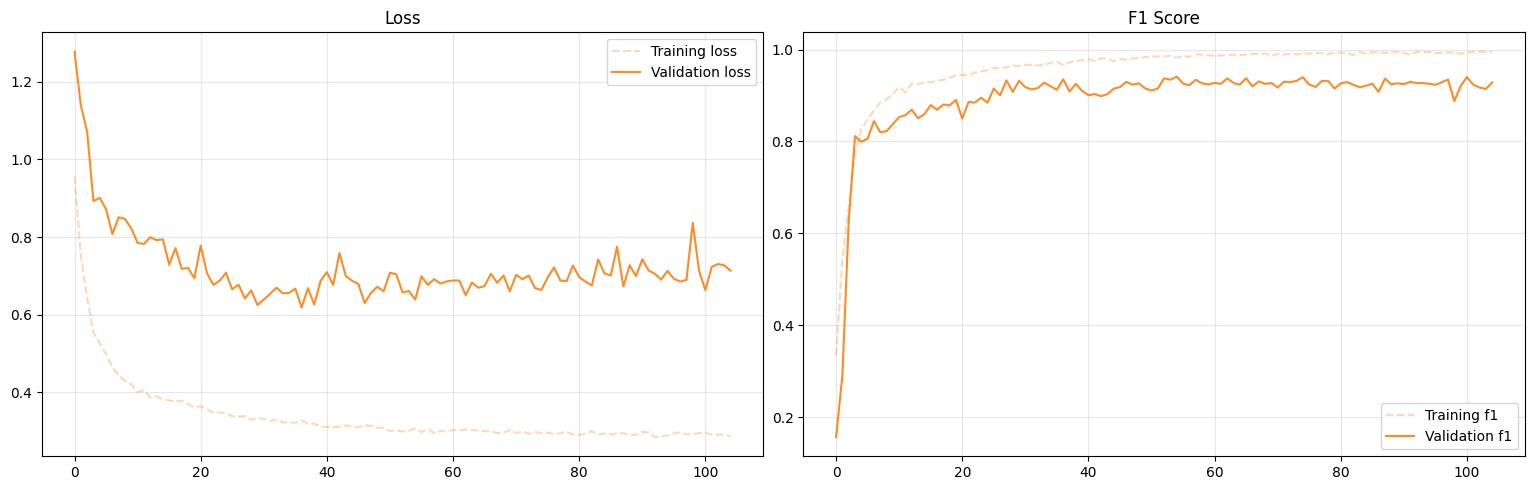

In [31]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first figure
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second figure
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Validation Accuracy: 0.9403
Precision (weighted): 0.9424
Recall (weighted): 0.9403
F1 Score (weighted): 0.9408

Detailed Classification Report:
              precision    recall  f1-score   support

     no_pain     0.9826    0.9637    0.9730       468
    low_pain     0.8261    0.9383    0.8786        81
   high_pain     0.7692    0.7407    0.7547        54

    accuracy                         0.9403       603
   macro avg     0.8593    0.8809    0.8688       603
weighted avg     0.9424    0.9403    0.9408       603



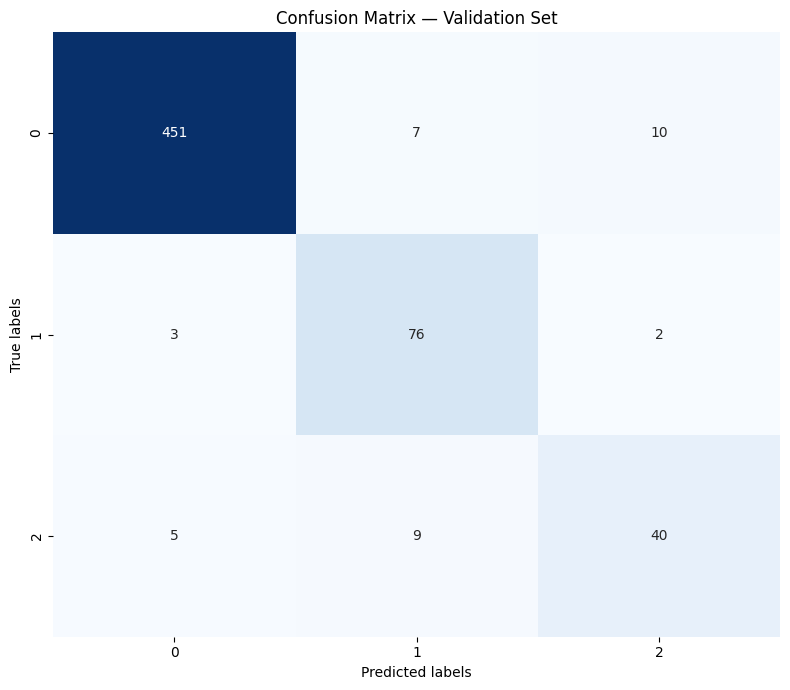

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

val_preds, val_targets = [], []

egru_model.eval()

with torch.no_grad():  
    for (cont, survey, body, time), yb in val_loader:
        cont = cont.to(device)
        survey = survey.to(device)
        body = body.to(device)
        time = time.to(device)
        yb = yb.to(device)
    
        logits = egru_model(cont, survey, body, time)
        preds = logits.argmax(dim=1).cpu().numpy()
    
        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())

val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')

print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Precision (weighted): {val_prec:.4f}")
print(f"Recall (weighted): {val_rec:.4f}")
print(f"F1 Score (weighted): {val_f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(
    val_targets, val_preds,
    target_names=['no_pain', 'low_pain', 'high_pain'],
    digits=4
))

cm = confusion_matrix(val_targets, val_preds)
cm_labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=cm_labels, fmt='', cmap='Blues', cbar=False)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

In [33]:
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

NUM_TEST_SAMPLES = 1324  
BATCH_SIZE = 64  

cont_test_tensor = X_test_seq["cont"].float()
survey_test_tensor = X_test_seq["survey"].long()
body_test_tensor = X_test_seq["body"].long()

if egru_model.use_time:
    time_test_tensor = X_test_seq["time"].long()
    test_ds = TensorDataset(cont_test_tensor, survey_test_tensor, body_test_tensor, time_test_tensor)
else:
    test_ds = TensorDataset(cont_test_tensor, survey_test_tensor, body_test_tensor)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

egru_model.eval()
test_preds = []

with torch.no_grad():
    if egru_model.use_time:
        for cont, survey, body, time in tqdm(test_loader, desc="Running inference"):
            cont = cont.to(device)
            survey = survey.to(device)
            body = body.to(device)
            time = time.to(device)
            
            logits = egru_model(cont, survey, body, time)
            preds = logits.argmax(dim=1).cpu().numpy()
            test_preds.append(preds)
    else:
        for cont, survey, body in tqdm(test_loader, desc="Running inference"):
            cont = cont.to(device)
            survey = survey.to(device)
            body = body.to(device)
            
            logits = egru_model(cont, survey, body)
            preds = logits.argmax(dim=1).cpu().numpy()
            test_preds.append(preds)

test_preds = np.concatenate(test_preds)
print(f"Raw window-level predictions: {test_preds.shape}")

windows_per_sample = len(test_preds) // NUM_TEST_SAMPLES
assert len(test_preds) % NUM_TEST_SAMPLES == 0, \
    "Number of predictions doesn't divide evenly into samples — check your windowing."

print(f"Windows per sample: {windows_per_sample}")

agg_preds = []
for i in range(NUM_TEST_SAMPLES):
    start = i * windows_per_sample
    end = (i + 1) * windows_per_sample
    preds_chunk = test_preds[start:end]
    majority = Counter(preds_chunk).most_common(1)[0][0]
    agg_preds.append(majority)

agg_preds = np.array(agg_preds)
print(f"Aggregated predictions: {agg_preds.shape}")

label_map = {0: "no_pain", 1: "low_pain", 2: "high_pain"}
labels = [label_map[p] for p in agg_preds]

sample_indices = [f"{i:03d}" for i in range(NUM_TEST_SAMPLES)]

submission = pd.DataFrame({
    "sample_index": sample_indices,
    "label": labels
})

submission.to_csv("submission.csv", index=False)

print("Egru submission file saved as submission.csv")
print(f"Rows in submission: {len(submission)}")

Running inference: 100%|██████████| 187/187 [00:02<00:00, 72.95it/s]

Raw window-level predictions: (11916,)
Windows per sample: 9
Aggregated predictions: (1324,)
Egru submission file saved as submission.csv
Rows in submission: 1324
